<details><summary style="display:list-item; font-size:16px; color:blue;">Jupyter Help</summary>
    
Having trouble testing your work? Double-check that you have followed the steps below to write, run, save, and test your code!
    
[Click here for a walkthrough GIF of the steps below](https://static-assets.codecademy.com/Courses/ds-python/jupyter-help.gif)

Run all initial cells to import libraries and datasets. Then follow these steps for each question:
    
1. Add your solution to the cell with `## YOUR SOLUTION HERE ## `.
2. Run the cell by selecting the `Run` button or the `Shift`+`Enter` keys.
3. Save your work by selecting the `Save` button, the `command`+`s` keys (Mac), or `control`+`s` keys (Windows).
4. Select the `Test Work` button at the bottom left to test your work.

![Screenshot of the buttons at the top of a Jupyter Notebook. The Run and Save buttons are highlighted](https://static-assets.codecademy.com/Paths/ds-python/jupyter-buttons.png)

**Setup**
Run the following cell to import libraries and helper function.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(42)

import pickle
with open('datasets/vocab_pickle.pkl', 'rb') as file:
    vocab = pickle.load(file)

print("Vocabulary Size:", len(vocab))
print("Vocabulary Preview:", dict(list(vocab.items())[:20]))

Vocabulary Size: 1002
Vocabulary Preview: {'to': 2, 'the': 3, 'and': 4, 'a': 5, 'in': 6, 'of': 7, 'you': 8, 'that': 9, 'is': 10, 'it': 11, 'can': 12, 'i': 13, 'for': 14, 'they': 15, 'be': 16, 'have': 17, 'are': 18, 'students': 19, 'people': 20, 'not': 21}


#### Checkpoint 1/3

**A.** Complete the neural network classification architecture by correctly implementing the embedding layer `self.embedding` given the input size equal to the vocabulary size (`vocab_size`) and outputs the embedding size (`embed_size`).

**B.** Define the following variables:
- `vocab_size`: Should be equal to the size of the vocabulary loaded in `vocab`.
- `embed_size`: Specify embedding sizes with `50` dimensions.
- `hidden_size`: Specify a hidden size of `100` units.
- `output_size`: Specify an output of `2` units.

**C.** Create an instance of the model given the variables above and save the model to the variable `text_classifier_model`.
- Load pre-trained weights from `"models/text_classifier_nn.pth"` and save them to the variable `state_dict`, and load them into the model. Be sure to set the model to evaluation mode.

**D.** Extract the embedding layer of the pre-trained classifier and save it to the variable `text_classifier_model`. 

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [2]:
## YOUR SOLUTION HERE ##
device = "cuda" if torch.cuda.is_available() else "cpu"
class SimpleNNWithEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SimpleNNWithEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.fc1 = nn.Linear(embed_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.embedding(x)
        x = torch.mean(x, dim=1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        
vocab_size = len(vocab)
embed_size = 50
hidden_size = 100
output_size = 2

text_classifier_model = SimpleNNWithEmbedding(vocab_size, embed_size, hidden_size, output_size)
state_dict = torch.load("models/text_classifier_nn.pth", map_location = device, weights_only = "True")
text_classifier_model.load_state_dict(state_dict)
text_classifier_model.eval()

embedding_layer = text_classifier_model.embedding.weight.detach().cpu().numpy()

# Show output
print(f"Embedding shape:", embedding_layer.shape)

Embedding shape: (1002, 50)


#### Checkpoint 2/3

**A.** Create a function named `token_similarity` that uses the extracted embedding layer to calculate the cosine similarity between two tokens in the vocabulary. The function should have the following inputs:
- `token1` and `token2`: Specify each token.
- `vocab`: Specify the vocabulary.
- `embedding_layer`: Specify the embedding layer.

The function should only return the cosine similarity.

**B.** Use the function to calculate the cosine similarity for the following token pairs saved to the following:

- `sim1`: Calculate the similarity between tokens `"school"` and `"student"`.
- `sim2`: Calculate the similarity between tokens `"school"` and `"work"`.
- `sim3`: Calculate the similarity between tokens `"school"` and `"phone"`.

Before calculating, which token pairs do you think have the highest and lowest similarity scores?

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

## YOUR SOLUTION HERE ##
def token_similarity(token1, token2, vocab, embedding_layer = embedding_layer):
    i, j = vocab[token1], vocab[token2]
    sim = cosine_similarity([embedding_layer[i]], [embedding_layer[j]])[0,0]
    return sim

sim1 = token_similarity("school", "student", vocab, embedding_layer = embedding_layer)
sim2 = token_similarity("school", "work", vocab, embedding_layer = embedding_layer)
sim3 = token_similarity("school", "phone", vocab, embedding_layer = embedding_layer)

# Show output - Cosine similarity scores for token pairs
print(f"Cosine Similarity (school, student): {sim1:.5}")
print(f"Cosine Similarity (school, work): {sim2:.5}")
print(f"Cosine Similarity (school, phone): {sim3:.5}")

Cosine Similarity (school, student): 0.0012185
Cosine Similarity (school, work): 0.37594
Cosine Similarity (school, phone): -0.17877


#### Checkpoint 3/3

Lastly, we've provided a function named `plot_embeddings` that visualizes 2-D token embeddings using matplotlib given a list of tokens to plot, the vocabulary, and embeddings.

**A.** Use **t-SNE** to transform our 50-D embeddings from `embedding_layer` into 2-D embeddings and save them to the variable `embeddings_2d`. Be sure to set the random state to `42`.

**B.** Create a list of tokens to plot to a variable named `tokens_to_plot`. The list should contain the following tokens: `"school", "students", "work", "phone", "people", "life", "positive", "negative", "company"`.

Use the function to visualize the embeddings in the list of tokens.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.ook for more det

In [4]:
from sklearn.manifold import TSNE

def plot_embeddings(tokens, vocab, embeddings):
    idxs = [vocab[w] for w in tokens if w in vocab]
    pts = embeddings[idxs]
    plt.figure(figsize=(7,6))
    plt.scatter(pts[:,0], pts[:,1], s=24)
    for (x,y), w in zip(pts, tokens):
        if w in vocab:
            plt.text(x+0.01, y+0.01, w, fontsize=9)
    plt.title("Word Embeddings (t-SNE, 2D)")
    plt.xlabel("dim-1"); plt.ylabel("dim-2")
    plt.tight_layout()
    plt.show()

## YOUR SOLUTION HERE ##
embeddings_2d = TSNE(n_components = 2, random_state = 42).fit_transform(embedding_layer)
tokens_to_plot = ["school", "students", "work", "phone", "people", "life", "positive", "negative", "company"]

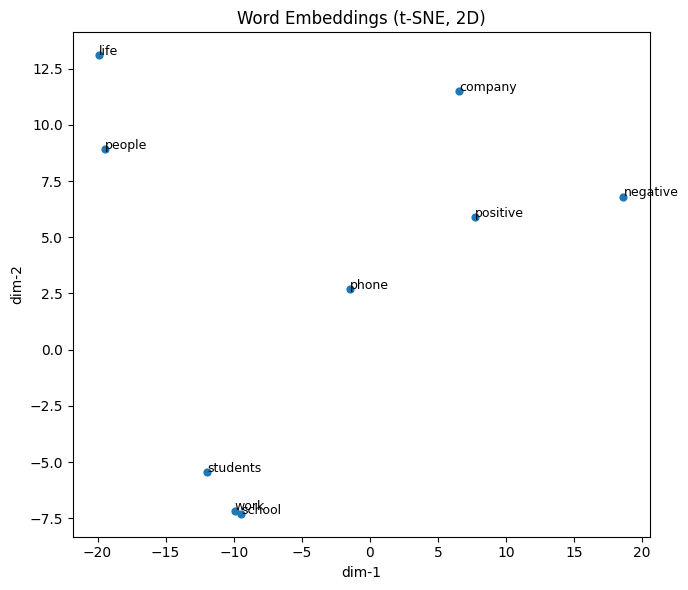

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

# Show output - Visualize Embeddings
plot_embeddings(tokens_to_plot, vocab, embeddings_2d)

Here are a few key observations:
- `"school"`, `"students"`, and `"work"` appear close to each other suggesting that the model has learned that they are semantically similar and share similar context.
- `"positive"` and `"negative"` are positioned  near each other but separate enough to suggest that this particular space may distinguish emotions and/or sentiment.
- `"company"` and `"work"` are noticeably far apart in 2-D space, even though they seem conceptually related. This doesn't mean that the model doesn't think they're unrelated. They may be relatively closer in the original 50-D space.